# DS7331 Project: Phishing Dataset

- Hayoung Cheon
- Steven Cox
- Erika Dupond
- Miguel Zavala


## Lab 2: Classification

You are to build upon the predictive analysis (classification) that you already completed in the
previous mini-project, adding additional modeling from new classification algorithms as well as
more explanations that are inline with the CRISP-DM framework.

### Dataset Selection
One classification task and one regression task.

1. Task1: One Classification  
- **Classifier**: Label  
- **Task**: To develop binary classification model that can accurately calssify whether a given URL is phishing or legitimate, based on a variety of URL-based and content-based featues.

2. Task2: One Regression  
- **Classifier**: URLTitleMatchScore  
- **Task**: To predict how well a URL matches the title of the webpage(quantified as URLTitleMatchScore) based on various features of the URL 

### General Import

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.svm import SVC, SVR
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
import time

%matplotlib inline

In [3]:
# Load dataset
url = "https://archive.ics.uci.edu/static/public/967/phiusiil+phishing+url+dataset.zip"
df = pd.read_csv(url, encoding="utf-8")
df = df.drop("FILENAME", axis=1)
print(f"Dataset shape: {df.shape}")
print(f"Label distribution: {df['label'].value_counts(normalize=True).round(3)}")
df.head()

Dataset shape: (235795, 55)
Label distribution: label
1    0.572
0    0.428
Name: proportion, dtype: float64


,URL,URLLength,Domain,DomainLength,IsDomainIP,TLD,URLSimilarityIndex,CharContinuationRate,TLDLegitimateProb,URLCharProb,...,Pay,Crypto,HasCopyrightInfo,NoOfImage,NoOfCSS,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,label
0,https://www.southbankmosaics.com,31,www.southbankmosaics.com,24,0,com,100.0,1.000000,0.522907,0.061933,...,0,0,1,34,20,28,119,0,124,1
1,https://www.uni-mainz.de,23,www.uni-mainz.de,16,0,de,100.0,0.666667,0.032650,0.050207,...,0,0,1,50,9,8,39,0,217,1
2,https://www.voicefmradio.co.uk,29,www.voicefmradio.co.uk,22,0,uk,100.0,0.866667,0.028555,0.064129,...,0,0,1,10,2,7,42,2,5,1
3,https://www.sfnmjournal.com,26,www.sfnmjournal.com,19,0,com,100.0,1.000000,0.522907,0.057606,...,1,1,1,3,27,15,22,1,31,1
4,https://www.rewildingargentina.org,33,www.rewildingargentina.org,26,0,org,100.0,1.000000,0.079963,0.059441,...,1,0,1,244,15,34,72,1,85,1


### Task 1: Classification
To predict whether a given URL is phishing or legitimate

### Data Preparation

#### Feature Engineering

In [4]:
# Extract numeric features
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols.remove('label')
X_numeric = df[numeric_cols].copy()

# TLD feature engineering
tld_phishing = df.groupby('TLD')['label'].agg(['count', 'mean'])
tld_phishing = tld_phishing.sort_values(by=['mean'], ascending=False)

tld_counts = df['TLD'].value_counts()
X_numeric['tld_frequency'] = df['TLD'].map(tld_counts.to_dict())
X_numeric['tld_frequency'] = pd.cut(X_numeric['tld_frequency'], 
                                   bins=[0, 10, 100, 1000, np.inf], 
                                   labels=[0, 1, 2, 3]).astype(int)

high_phish_tlds = tld_phishing[tld_phishing['mean'] > 0.9].index.tolist()
X_numeric['is_high_phish_tld'] = df['TLD'].isin(high_phish_tlds).astype(int)

# Domain feature engineering
domain_counts = df['Domain'].value_counts()
X_numeric['domain_frequency'] = df['Domain'].map(domain_counts.to_dict())
X_numeric['domain_frequency'] = pd.cut(X_numeric['domain_frequency'], 
                                      bins=[0, 1, 5, 50, np.inf], 
                                      labels=[0, 1, 2, 3])
X_numeric['domain_frequency'] = X_numeric['domain_frequency'].astype(int)

# Title feature engineering
title_counts = df['Title'].value_counts()
X_numeric['title_frequency'] = df['Title'].map(title_counts.to_dict())
X_numeric['title_frequency'] = pd.cut(X_numeric['title_frequency'], 
                                     bins=[0, 1, 5, np.inf], 
                                     labels=[0, 1, 2]).astype(int)
X_numeric['title_length'] = df['Title'].str.len()

# Handle remaining categorical columns
remaining_categorical = df.select_dtypes(include=['object']).columns.tolist()
remaining_categorical = [col for col in remaining_categorical if col not in ['URL', 'Domain', 'TLD', 'Title', 'label']]

if len(remaining_categorical) > 0:
    le = LabelEncoder()
    for col in remaining_categorical:
        X_numeric[col] = le.fit_transform(df[col].astype(str))

X = X_numeric
y = df['label']

print(f"Features: {X.shape[1]}, Samples: {X.shape[0]:,}")
print(f"Added features: {len([col for col in X.columns if col.startswith(('tld_', 'domain_', 'title_', 'is_'))])}")

Features: 55, Samples: 235,795
Added features: 5


### Data Splitting and Scaling -> See if we want to keep here or down there.

In [5]:
# Train/validation/test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: 141,477 | Val: 47,159 | Test: 47,159


### Modeling and Evaluation

#### Evaluation Metrics
- **Accuracy**: Proportion of correct predictions (both phishing and legitimate) over total predictions
- **F1**: Harmonic mean of precision and recall. Best when we need a balance between catching phishing attacks and minimizing false positives. 
- **Precision**: Of all URLs predicted as phishing, how many were truly phishing: will avoid false positive
- **Recall**: Of all actual phishing URL's, how many did the model correctly catch? will useful for minimizing false negative.
- **AUC**: Measures how well the model ranks phishing URLs higher then legitimate ones across all threholds.

In [6]:
def evaluate_model(name, model, X_train, X_val, X_test, y_train, y_val, y_test):
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time
    
    val_pred = model.predict(X_val)
    test_pred = model.predict(X_test)
    
    try:
        val_proba = model.predict_proba(X_val)[:, 1]
        test_proba = model.predict_proba(X_test)[:, 1]
        val_auc = roc_auc_score(y_val, val_proba)
        test_auc = roc_auc_score(y_test, test_proba)
    except:
        val_auc = test_auc = None
    
    val_acc = accuracy_score(y_val, val_pred)
    test_acc = accuracy_score(y_test, test_pred)
    val_f1 = f1_score(y_val, val_pred)
    test_f1 = f1_score(y_test, test_pred)
    val_precision = precision_score(y_val, val_pred)
    test_precision = precision_score(y_test, test_pred)
    val_recall = recall_score(y_val, val_pred)
    test_recall = recall_score(y_test, test_pred)
    
    tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()
    specificity = tn / (tn + fp)
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0
    
    print(f"{name}:")
    print(f"  Val: Acc={val_acc:.4f}, F1={val_f1:.4f}, Prec={val_precision:.4f}, Rec={val_recall:.4f}" + 
          (f", AUC={val_auc:.4f}" if val_auc else ""))
    print(f"  Test: Acc={test_acc:.4f}, F1={test_f1:.4f}, Prec={test_precision:.4f}, Rec={test_recall:.4f}" + 
          (f", AUC={test_auc:.4f}" if test_auc else ""))
    print(f"  Additional: Specificity={specificity:.4f}, NPV={npv:.4f}, Time={training_time:.3f}s")
    
    return {
        'val_acc': val_acc, 'test_acc': test_acc,
        'val_f1': val_f1, 'test_f1': test_f1,
        'val_precision': val_precision, 'test_precision': test_precision,
        'val_recall': val_recall, 'test_recall': test_recall,
        'val_auc': val_auc, 'test_auc': test_auc,
        'specificity': specificity, 'npv': npv,
        'training_time': training_time
    }

results = {}

#### Data Splitting and Scaling

In [7]:
# Train/validation/test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

Train: 141,477 | Val: 47,159 | Test: 47,159


#### 1. Decision Tree

In [8]:
dt_model = DecisionTreeClassifier(max_depth=15, min_samples_split=50, min_samples_leaf=20, random_state=42)
results['Decision Tree'] = evaluate_model('Decision Tree', dt_model, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)

Decision Tree:
  Val: Acc=0.9998, F1=0.9998, Prec=0.9996, Rec=1.0000, AUC=1.0000
  Test: Acc=0.9997, F1=0.9998, Prec=0.9996, Rec=1.0000, AUC=1.0000
  Additional: Specificity=0.9994, NPV=1.0000, Time=0.253s


#### 2.Random Forest

In [9]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=20, min_samples_split=50, min_samples_leaf=20, random_state=42, n_jobs=-1)
results['Random Forest'] = evaluate_model('Random Forest', rf_model, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)

Random Forest:
  Val: Acc=1.0000, F1=1.0000, Prec=1.0000, Rec=1.0000, AUC=1.0000
  Test: Acc=1.0000, F1=1.0000, Prec=0.9999, Rec=1.0000, AUC=1.0000
  Additional: Specificity=0.9999, NPV=1.0000, Time=0.723s


#### 3. K-Nearest Neighbors with Hyperparameter Tuning

In [10]:
param_grid = {'n_neighbors': [3, 5, 7, 9, 11]}
knn_base = KNeighborsClassifier(weights='distance', algorithm='auto', n_jobs=-1)

grid_search = GridSearchCV(knn_base, param_grid, cv=3, scoring='f1', n_jobs=-1)
grid_search.fit(X_train_scaled, y_train)

best_k = grid_search.best_params_['n_neighbors']
print(f"Best K: {best_k}, CV Score: {grid_search.best_score_:.4f}")

knn_model = KNeighborsClassifier(n_neighbors=best_k, weights='distance', algorithm='auto', n_jobs=-1)
results['KNN'] = evaluate_model('KNN', knn_model, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)

Best K: 3, CV Score: 0.9985
KNN:
  Val: Acc=0.9988, F1=0.9990, Prec=0.9982, Rec=0.9997, AUC=0.9993
  Test: Acc=0.9986, F1=0.9988, Prec=0.9981, Rec=0.9994, AUC=0.9992
  Additional: Specificity=0.9974, NPV=0.9993, Time=0.021s


#### 4. SVM

In [11]:
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42)
results['SVM (RBF Kernel)'] = evaluate_model('SVM (RBF Kernel)', svm_model, X_train_scaled, X_val_scaled, X_test_scaled, y_train, y_val, y_test)

SVM (RBF Kernel):
  Val: Acc=0.9999, F1=0.9999, Prec=0.9997, Rec=1.0000, AUC=1.0000
  Test: Acc=0.9999, F1=0.9999, Prec=0.9997, Rec=1.0000, AUC=1.0000
  Additional: Specificity=0.9997, NPV=1.0000, Time=212.654s


#### Results Summary

In [12]:
results_df = pd.DataFrame(results).T.sort_values('val_f1', ascending=False)

print("=" * 80)
for model, row in results_df.iterrows():
    print(f"\n{model}:")
    print(f"  Performance: Acc={row['test_acc']:.4f}, F1={row['test_f1']:.4f}, Precision={row['test_precision']:.4f}")
    print(f"  Reliability: Recall={row['test_recall']:.4f}, Specificity={row['specificity']:.4f}, NPV={row['npv']:.4f}")
    auc_str = f", AUC={row['test_auc']:.4f}" if row['test_auc'] is not None else ""
    print(f"  Speed: Time={row['training_time']:.3f}s{auc_str}")


Random Forest:
  Performance: Acc=1.0000, F1=1.0000, Precision=0.9999
  Reliability: Recall=1.0000, Specificity=0.9999, NPV=1.0000
  Speed: Time=0.723s, AUC=1.0000

SVM (RBF Kernel):
  Performance: Acc=0.9999, F1=0.9999, Precision=0.9997
  Reliability: Recall=1.0000, Specificity=0.9997, NPV=1.0000
  Speed: Time=212.654s, AUC=1.0000

Decision Tree:
  Performance: Acc=0.9997, F1=0.9998, Precision=0.9996
  Reliability: Recall=1.0000, Specificity=0.9994, NPV=1.0000
  Speed: Time=0.253s, AUC=1.0000

KNN:
  Performance: Acc=0.9986, F1=0.9988, Precision=0.9981
  Reliability: Recall=0.9994, Specificity=0.9974, NPV=0.9993
  Speed: Time=0.021s, AUC=0.9992


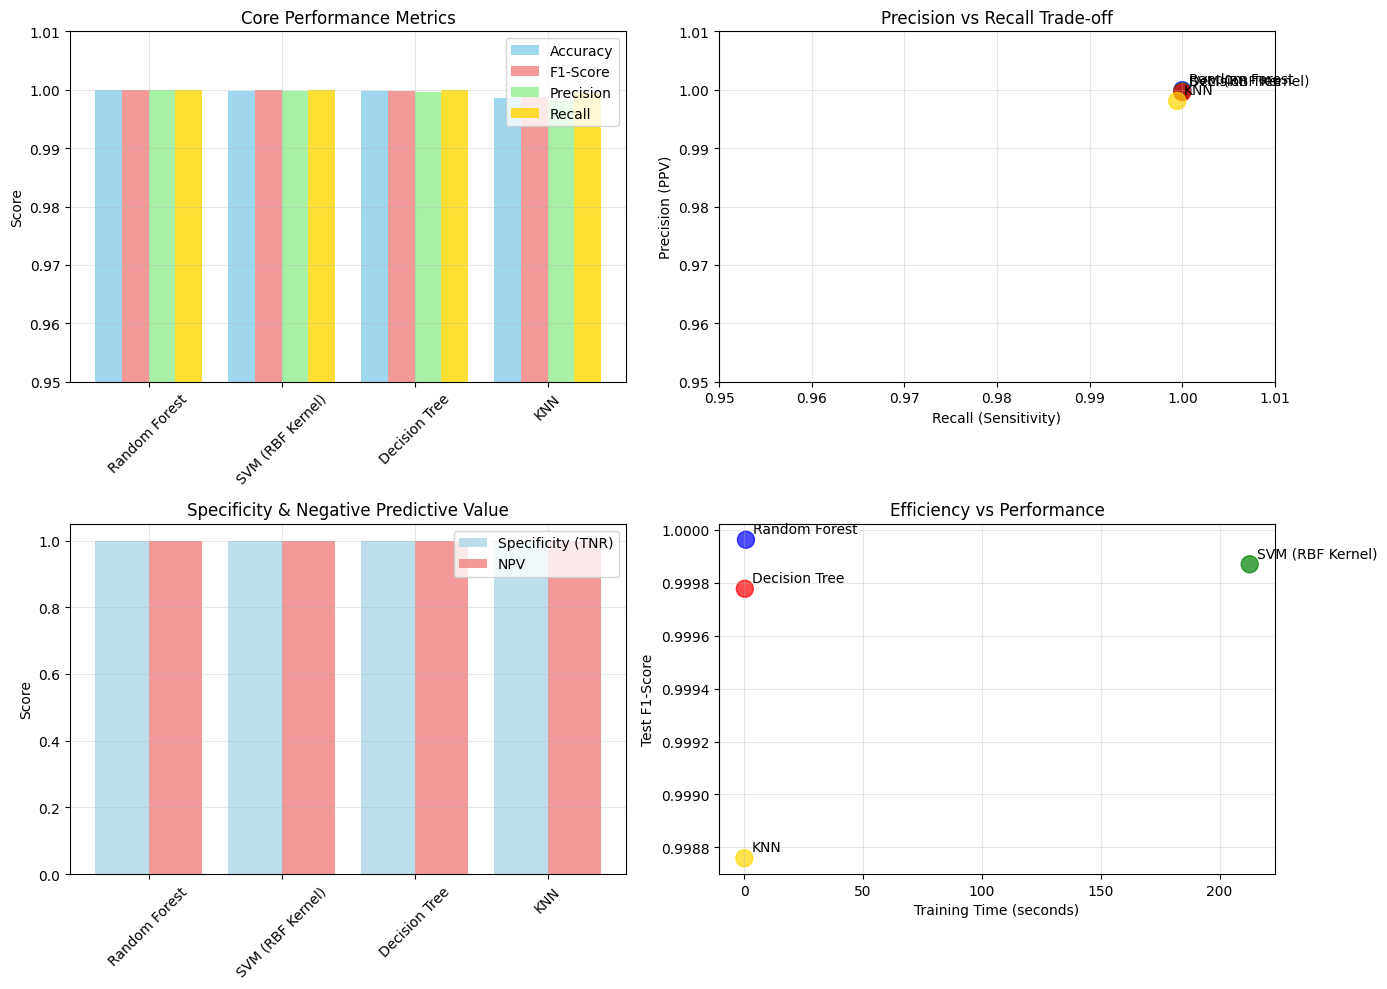

In [13]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

models = results_df.index
x = np.arange(len(models))

metrics = ['test_acc', 'test_f1', 'test_precision', 'test_recall']
metric_labels = ['Accuracy', 'F1-Score', 'Precision', 'Recall']
colors = ['skyblue', 'lightcoral', 'lightgreen', 'gold']

for i, (metric, label, color) in enumerate(zip(metrics, metric_labels, colors)):
    ax1.bar(x + i*0.2 - 0.3, results_df[metric], width=0.2, label=label, color=color, alpha=0.8)

ax1.set_title('Core Performance Metrics')
ax1.set_ylabel('Score')
ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0.95, 1.01)

ax2.scatter(results_df['test_recall'], results_df['test_precision'], s=150, alpha=0.7, c=['blue', 'green', 'red', 'gold'])
for model in models:
    ax2.annotate(model, (results_df.loc[model, 'test_recall'], results_df.loc[model, 'test_precision']), 
                xytext=(5, 5), textcoords='offset points')
ax2.set_title('Precision vs Recall Trade-off')
ax2.set_xlabel('Recall (Sensitivity)')
ax2.set_ylabel('Precision (PPV)')
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0.95, 1.01)
ax2.set_ylim(0.95, 1.01)

x_pos = np.arange(len(models))
ax3.bar(x_pos - 0.2, results_df['specificity'], width=0.4, label='Specificity (TNR)', alpha=0.8, color='lightblue')
ax3.bar(x_pos + 0.2, results_df['npv'], width=0.4, label='NPV', alpha=0.8, color='lightcoral')
ax3.set_title('Specificity & Negative Predictive Value')
ax3.set_ylabel('Score')
ax3.set_xticks(x_pos)
ax3.set_xticklabels(models, rotation=45)
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.scatter(results_df['training_time'], results_df['test_f1'], s=150, alpha=0.7, c=['blue', 'green', 'red','gold'])
for model in models:
    ax4.annotate(model, (results_df.loc[model, 'training_time'], results_df.loc[model, 'test_f1']), 
                xytext=(5, 5), textcoords='offset points')
ax4.set_title('Efficiency vs Performance')
ax4.set_xlabel('Training Time (seconds)')
ax4.set_ylabel('Test F1-Score')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Task 2: Regression
To predict how tell a URL matches the title of the webpage(URLTitleMatchScore)

### Data Preparation

#### Show correlation of URLTitleMatchScore and other numeric variables

In [14]:
# Keep numeric columns only
numeric_df = df.select_dtypes(include=[np.number])


print("Correlation with URLTitleMatchScore:")
print(numeric_df.corr()['URLTitleMatchScore'].sort_values(ascending=False))


Correlation with URLTitleMatchScore:
URLTitleMatchScore            1.000000
DomainTitleMatchScore         0.961008
CharContinuationRate          0.568560
URLSimilarityIndex            0.543969
label                         0.539419
HasSocialNet                  0.425394
HasTitle                      0.417060
HasCopyrightInfo              0.413144
HasDescription                0.398488
URLCharProb                   0.331182
HasSubmitButton               0.302893
IsResponsive                  0.297164
TLDLegitimateProb             0.296253
HasHiddenFields               0.265098
HasFavicon                    0.245452
Robots                        0.222834
IsHTTPS                       0.220749
Pay                           0.203851
NoOfJS                        0.199003
TLDLength                     0.169064
NoOfSelfRef                   0.161625
NoOfImage                     0.150345
LineOfCode                    0.146272
NoOfiFrame                    0.142916
NoOfExternalRef            

#### Removing Leakage, High Correleation, and Irrelevant Features

In [15]:
leak_columns = [
    # 'Title',                  # UrlTitleMatchScore is derived from Title.
    'DomainTitleMatchScore',  # Extremely high correlation; direct overlap
    'label'                   # Phishing would cause leakage as it was the original target.
]

# Drop from feature matrix
numeric_df = numeric_df.drop(columns=leak_columns)

print("Remaining columns after dropping potential leaks:")
print(numeric_df.columns.tolist())

Remaining columns after dropping potential leaks:
['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']


### Modeling and Evaluation
#### Evaluation Maetrics and test/train split

In [16]:
# Define X and y
X = numeric_df.drop('URLTitleMatchScore', axis=1)
y = numeric_df['URLTitleMatchScore']

# Drop known leaks
leak_columns = ['DomainTitleMatchScore', 'label']
X = X.drop(columns=[col for col in leak_columns if col in X.columns])

print("Remaining features:", X.columns.tolist())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Remaining features: ['URLLength', 'DomainLength', 'IsDomainIP', 'URLSimilarityIndex', 'CharContinuationRate', 'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain', 'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL', 'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL', 'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL', 'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength', 'HasTitle', 'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect', 'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef', 'NoOfEmptyRef', 'NoOfExternalRef']
Training samples: 188636
Testing samples: 47159


#### Scale Features

In [17]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We use **10-Fold Cross-Validation** (`KFold`) to get a reliable estimate of generalization performance.
Each fold trains on 90% of the training data and tests on 10%.

**Why 10 folds?**
- Good balance between bias and variance.
- Works well for medium-sized datasets.
- Uses as much data as possible for training each round.

**Evaluation metrics:**
- **MAE (Mean Absolute Error):** Average absolute difference between predicted and actual values.
- **RMSE (Root Mean Squared Error):** Penalizes larger errors more strongly.
- **R² (R-Squared):** Proportion of variance explained by the model.

Combining these metrics gives a better sense of how well the model performs.

In [18]:
# Define K-Fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Define scoring
scoring = {
    'MAE': 'neg_mean_absolute_error',
    'RMSE': 'neg_root_mean_squared_error',
    'R2': 'r2'
}

#### 1. Random Forest

In [19]:

rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

rf_scores = cross_validate(rf, X_train_scaled, y_train, cv=kf, scoring=scoring)

rf_results = {
    'MAE': -rf_scores['test_MAE'].mean(),
    'RMSE': -rf_scores['test_RMSE'].mean(),
    'R2': rf_scores['test_R2'].mean()
}

print(rf_results)


{'MAE': np.float64(9.905770696631807), 'RMSE': np.float64(21.72320497457532), 'R2': np.float64(0.8081467516918572)}


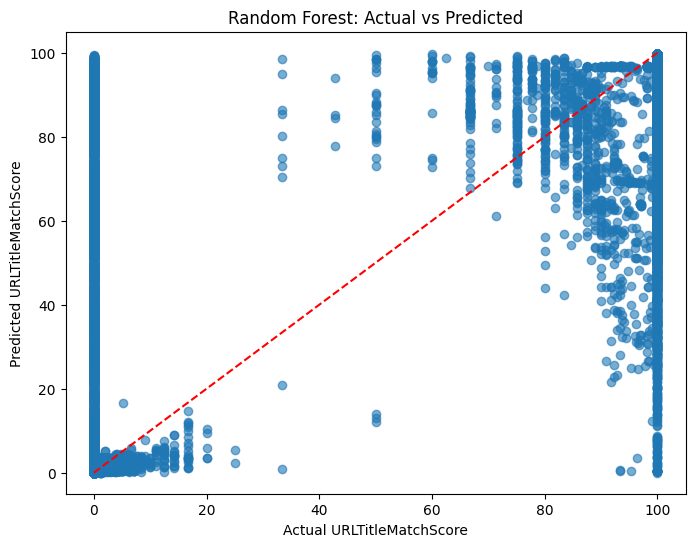

                       Feature    Importance
19  NoOfOtherSpecialCharsInURL  5.513293e-01
24                    HasTitle  2.071783e-01
3           URLSimilarityIndex  8.138150e-02
8                NoOfSubDomain  6.566564e-02
7                    TLDLength  2.442332e-02
5            TLDLegitimateProb  1.801818e-02
13            LetterRatioInURL  8.698806e-03
6                  URLCharProb  7.565629e-03
12            NoOfLettersInURL  6.698899e-03
4         CharContinuationRate  4.570862e-03
20       SpacialCharRatioInURL  4.244652e-03
1                 DomainLength  2.994530e-03
22                  LineOfCode  2.836803e-03
0                    URLLength  2.289966e-03
23           LargestLineLength  1.632256e-03
29            NoOfSelfRedirect  1.546815e-03
21                     IsHTTPS  1.294535e-03
15             DegitRatioInURL  1.108238e-03
47             NoOfExternalRef  9.258342e-04
45                 NoOfSelfRef  7.592698e-04
42                   NoOfImage  7.463313e-04
14        

In [20]:

rf.fit(X_train_scaled, y_train)
y_pred = rf.predict(X_test_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual URLTitleMatchScore')
plt.ylabel('Predicted URLTitleMatchScore')
plt.title('Random Forest: Actual vs Predicted')
plt.show()

feature_names = X_train.columns

# Get importances
importances = rf.feature_importances_

# Make a DataFrame for easy sorting
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

#### 2. K-Nearest Neighbors Regression

In [21]:

knn = KNeighborsRegressor(n_neighbors=5)

knn_scores = cross_validate(knn, X_train_scaled, y_train, cv=kf, scoring=scoring)

knn_results = {
    'MAE': -knn_scores['test_MAE'].mean(),
    'RMSE': -knn_scores['test_RMSE'].mean(),
    'R2': knn_scores['test_R2'].mean()
}

print(knn_results)

{'MAE': np.float64(10.702598559250383), 'RMSE': np.float64(24.733844222116495), 'R2': np.float64(0.7512812891093427)}


#### 3. Support Vector Regression

In [ ]:
svr = SVR(kernel='rbf', C=1.0, epsilon=0.1)

svr_scores = cross_validate(svr, X_train_scaled, y_train, cv=kf, scoring=scoring, n_jobs=-1)

svr_results = {
    'MAE': -svr_scores['test_MAE'].mean(),
    'RMSE': -svr_scores['test_RMSE'].mean(),
    'R2': svr_scores['test_R2'].mean()
}

print(svr_results)

### Results Summary and Model comparison

In [ ]:
comparison = pd.DataFrame({
    'Random Forest': rf_results,
    'KNN': knn_results,
    'SVR': svr_results
})

print(comparison)

comparison.T.plot(kind='bar', figsize=(10,6), title='Regression Model Comparison')

#### Each models advantages for each classification task.

##### Task1: Calssification
- **Decision Tree**: The advantages of Decision Tree is that it is interpretable as we can visualize decisions and it's fast to train. The model handles binary outcomes with straightforward decision paths. However, it is unsable as small changes can change tree structure significantly. 
- **Random Forest**: It helps reducing overfitting via ensembling and it is robust and performs well on varied features. However, it is less interpretable.
- **KNN**: It's simple to implement and naturally captures nonlinear boundaries. However, it is poor on high-dimensional data which leads to curse of dimensionality.
- **SVM**: The model is effective in high-dimensional space and it is robust to overfitting with proper regualrizaiton. 

How to konw the **Statistical Comparison**. 